In [1]:
import sys
import os
import numpy as np
import pandas as pd

In [2]:
eye_data_path = '/data/pt_02747/action_hippo/data/derivatives/eyetracker/'
event_data_path = '/data/pt_02747/action_hippo/data/'
subs_path = '/data/pt_02747/action_hippo/data/derivatives/'

# subs are all subjects in event_data_path
subs = os.listdir(event_data_path)
subs = [sub for sub in subs if 'sub' in sub]
subs = [sub for sub in subs if '.' not in sub]
subs = sorted(subs)

#bad_subs = ['03', '04', '05', '06', '08', '09', '32', '35', '40', '41', '45', '50', '57']
#bad_subs = ['sub-' + sub for sub in bad_subs]
#subs = [sub for sub in subs if sub not in bad_subs]
len(subs)


57

In [3]:
sub = subs[0]
# create empty df with columns "sub", "condition", "mean_x", "mean_y", "window", "method"


In [4]:

# get event files, which are divided by runs, and append into one big df

for run in ['01', '02', '03', '04']:
    # get event files
    event_file = os.path.join(eye_data_path, sub, sub + '_task-probe_run-' + run + '_events.tsv')
    # read in event file
    df = pd.read_csv(event_file, sep='\t')
    # add run column
    df['run'] = run[-1]
    # append to big df
    if run == '01':
        df_all = df
    else:
        df_all = pd.concat([df_all, df], axis=0)

df_all.head()

,onset,duration,trial_type,stimulus,run
0,358.799436,2.0,3,33.0,1
1,358.799436,2.0,stimulus,33.0,1
2,362.381885,2.0,stimulus,34.0,1
3,362.381885,2.0,4,34.0,1
4,365.414362,2.0,stimulus,61.0,1


In [6]:
# get eye data files, which are in one big file
# get files in sub folder
files = os.listdir(os.path.join(eye_data_path, sub))
# get only eye data files
files = [file for file in files if 'eye' in file and 'cleaned' in file and 'csv' in file]
file = files[0]

print(files)

# read in eye data file
df_eye = pd.read_csv(os.path.join(eye_data_path, sub, file), sep=',')
df_eye.head()


['sub-01_eye_data_20230601_1624_cleaned.csv']


,time_rounded,time,left_gaze_x,left_gaze_y,left_pupil_measure1,right_gaze_x,right_gaze_y,right_pupil_measure1,status,status_buffer_100,mean_gaze_x,mean_gaze_y
0,318.580,318.580091,-0.030093,0.051389,1666.0,-0.017037,0.061111,1518.0,0.0,0.0,-0.023565,0.056250
1,318.581,318.581244,-0.028704,0.048889,1670.0,-0.016667,0.057407,1528.0,0.0,0.0,-0.022685,0.053148
2,318.582,318.582258,-0.030000,0.049259,1670.0,-0.016852,0.058796,1529.0,0.0,0.0,-0.023426,0.054028
3,318.583,318.583425,-0.029537,0.051204,1670.0,-0.016574,0.060000,1530.0,0.0,0.0,-0.023056,0.055602
4,318.585,318.584564,-0.029259,0.050556,1667.0,-0.017315,0.059352,1529.0,0.0,0.0,-0.023287,0.054954


In [7]:
# optimise processing time by excluding any timestamps before the first onset
# get first onset
first_onset = df_all['onset'].min()
# exclude rows in eye data before first onset
df_eye = df_eye[df_eye['time'] >= first_onset-1]

In [9]:
# get subject baseline for gaze to exclude anything weird
# baseline is median of whole eye data file for mean x and y
baseline_x = df_eye['mean_gaze_x'].median()
baseline_y = df_eye['mean_gaze_y'].median()
baseline_x

-0.0008796127513051

In [10]:
# get onsets of events for each condition in df_all

conditions = ['1', '2', '3', '4']

onsets_cond = {}

for cond in conditions:
    onsets_cond_unrounded = df_all[df_all['trial_type'] == cond]['onset'].values
    # round to 3dp
    onsets_cond_rounded = np.round(onsets_cond_unrounded, 3)
    onsets_cond[cond] = onsets_cond_rounded


In [11]:
# for each condition, take onsets, get median x and y coordinates for interval in 1000 to 2000ms after onset

window = [0.85, 0.87]

# create list of timecourse intervals, which are values in range 0,2 with step 0.001
timecourse_vals = np.arange(window[0], window[1], 0.001)

summary_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "time", "method"])

for cond in conditions:
    onsets = onsets_cond[cond]
    
    # create empty 2d array for median x and y coordinates, with length of onsets
    median_x = np.empty(len(onsets))
    median_y = np.empty(len(onsets))

    # for each onset, get median x and y coordinates for interval in 1000 to 2000ms after onset
    for onset_i in range(len(onsets)):
        time_window_start = onsets[onset_i] + window[0] # start is inclusive
        time_window_end = onsets[onset_i] + window[1] # end is not inclusive

        df_window = df_eye[(df_eye['time'] >= time_window_start) & (df_eye['time'] <= time_window_end)] # get rows in time window

        # exclude rows with missing data, e.g. nans in mean gaze
        df_window = df_window[df_window['mean_gaze_x'].notna()]
        df_window = df_window[df_window['mean_gaze_y'].notna()]

        median_x[onset_i] = df_window['mean_gaze_x'].median() # mean gaze means the mean of the left and right eye
        median_y[onset_i] = df_window['mean_gaze_y'].median() # mean gaze means the mean of the left and right eye


    # get median x and y for each timecourse value post onset
    for timecourse_val in timecourse_vals:
        list_vals_x = []
        list_vals_y = []
        for onset in onsets:
            timepoint = onset + timecourse_val
            # see if we have any x or y values for this timepoint
            df_timepoint = df_eye[(df_eye['time_rounded'] == timepoint)]

            #print('timepoint: ', timepoint)
            # print df_timepoint
            #print('timepoint: ', df_timepoint)

            if len(df_timepoint) == 0:
                list_vals_x.append(np.nan)
                list_vals_y.append(np.nan)
            else:
                list_vals_x.append(df_timepoint['mean_gaze_x'].median() - baseline_x)
                list_vals_y.append(df_timepoint['mean_gaze_y'].median() - baseline_y)
        

        # remove nans
        list_vals_x = [x for x in list_vals_x if str(x) != 'nan']
        list_vals_y = [y for y in list_vals_y if str(y) != 'nan']

        # ideal is number of trials per condition * 4, which should be 64
        print('x values: ', len(list_vals_x))

        # take median of all values for this timepoint
        timepoint_median_x = np.median(list_vals_x)
        timepoint_median_y = np.median(list_vals_y)

        # concat to timecourse df
        row_df = pd.DataFrame([[sub, cond, timepoint_median_x, timepoint_median_y, timecourse_val, 'median']], columns=["sub", "condition", "mean_x", "mean_y", "time", "method"])
        timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)
        

    # take mean of median x and y coordinates to give one value for each condition
    median_x = median_x[~np.isnan(median_x)]
    median_y = median_y[~np.isnan(median_y)]

    mean_x = median_x.mean() - baseline_x
    mean_y = median_y.mean() - baseline_y
    # concat to summary df
    row_df = pd.DataFrame([[sub, cond, mean_x, mean_y, str(window[0])+'_'+str(window[1]), 'median']], columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
    # concat to summary df
    summary_df = pd.concat([summary_df, row_df], ignore_index=True)


x values:  34
x values:  42


/tmp/ipykernel_23217/3885994669.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)


x values:  36
x values:  48
x values:  44
x values:  46
x values:  57
x values:  46
x values:  41
x values:  32
x values:  37
x values:  37
x values:  40
x values:  42
x values:  43
x values:  56
x values:  52
x values:  43
x values:  34
x values:  29
x values:  37


/tmp/ipykernel_23217/3885994669.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([summary_df, row_df], ignore_index=True)


x values:  30
x values:  45
x values:  39
x values:  40
x values:  46
x values:  50
x values:  53
x values:  38
x values:  35
x values:  29
x values:  35
x values:  45
x values:  37
x values:  44
x values:  47
x values:  53
x values:  50
x values:  38
x values:  35
x values:  30
x values:  32
x values:  43
x values:  39
x values:  27
x values:  29
x values:  44
x values:  45
x values:  47
x values:  42
x values:  36
x values:  41
x values:  38
x values:  34
x values:  31
x values:  40
x values:  46
x values:  52
x values:  46
x values:  40
x values:  43
x values:  39
x values:  39
x values:  30
x values:  38
x values:  37
x values:  44
x values:  35
x values:  42
x values:  48
x values:  40
x values:  44
x values:  29
x values:  33
x values:  36
x values:  41
x values:  36
x values:  41
x values:  49
x values:  47
x values:  45
x values:  31
x values:  33
x values:  34


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


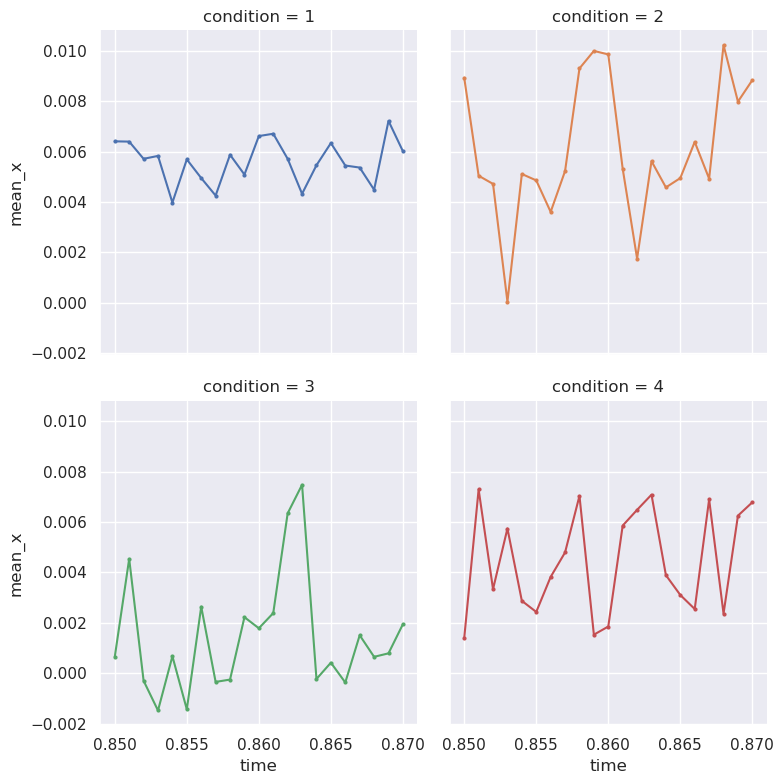

In [14]:
# plot timecourse of gaze for each condition
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")

g = sns.FacetGrid(timecourse_df, col="condition", hue="condition", col_wrap=2, height=4)
g.map(plt.plot, "time", "mean_x", marker="o", ms=2)

Try with all subs

In [5]:
import copy

# create empty df with columns "sub", "condition", "mean_x", "mean_y", "window", "method"
summary_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
# create empty df with columns "sub", "condition", "mean_x", "mean_y", "time", "method"
#timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "time", "method", 'num_xvals', 'num_yvals'])

timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_gaze_x", "mean_gaze_y", "time_rounded_relative", "method"])

# create empty df with columns "sub", "condition", "onset", "run", "data"
trials_used_df = pd.DataFrame(columns=["sub", "condition", "onset", "run", "data", 'data_num'])

# list conditions
conditions = ['1', '2', '3', '4']
# time window in which to carry out analyses
window = [-0.501, 2.5]

# create list of timecourse intervals, which are values in range 0,2 with step 0.001
timecourse_vals = np.arange(window[0], window[1], 0.001)

for sub in subs:
    print('processing sub', sub)
    try:
        # =============================================================================
        # get event files, which are divided by runs, and append into one big df
        for run in ['01', '02', '03', '04']:
            # get event files
            event_file = os.path.join(eye_data_path, sub, sub + '_task-probe_run-' + run + '_events.tsv')
            # read in event file
            df = pd.read_csv(event_file, sep='\t')
            # add run column
            df['run'] = run[-1]
            # append to big df
            if run == '01':
                df_all = df
            else:
                df_2 = df
                # concatenate
                df_all = pd.concat([df_all, df_2], ignore_index=True)

        # get eye data files, which are in one big file
        # get files in sub folder
        files = os.listdir(os.path.join(eye_data_path, sub))
        # get only eye data files
        files = [file for file in files if 'eye' in file and 'cleaned' in file and 'csv' in file]
        file = files[0]

        # =============================================================================

        # read in eye data file
        df_eye = pd.read_csv(os.path.join(eye_data_path, sub, file), sep=',')

        # we only need 'time_rounded', 'mean_gaze_x', 'mean_gaze_y'
        df_eye = df_eye[['time','time_rounded', 'mean_gaze_x', 'mean_gaze_y']]


        # =============================================================================

        # exlude points where mean_gaze_y is less than -0.5 or greater than 0.5
        df_eye = df_eye[df_eye['mean_gaze_y'] >= -0.5]
        df_eye = df_eye[df_eye['mean_gaze_y'] <= 0.5]

        # exclude points where mean_gaze_x is less than -0.89 or greater than 0.89
        df_eye = df_eye[df_eye['mean_gaze_x'] >= -0.5]
        df_eye = df_eye[df_eye['mean_gaze_x'] <= 0.5]

        # =============================================================================

        # optimise processing time by excluding any timestamps before the first onset
        # get first onset
        first_onset = df_all['onset'].min()
        # exclude rows in eye data before first onset
        df_eye = df_eye[df_eye['time'] >= first_onset-1]

        # =============================================================================

        # get subject baseline for gaze to exclude anything weird
        # baseline is median of whole eye data file for mean x and y
        baseline_x = df_eye['mean_gaze_x'].median()
        #print('baseline_x', baseline_x)
        baseline_y = df_eye['mean_gaze_y'].median()

        # =============================================================================

        # get onsets of events for each condition in df_all

        onsets_cond = {}

        for cond in conditions:
            onsets_cond_unrounded = df_all[df_all['trial_type'] == cond]['onset'].values
            # round to 3dp
            onsets_cond_rounded = np.round(onsets_cond_unrounded, 3)
            onsets_cond[cond] = onsets_cond_rounded

        # =============================================================================

        # for each condition, take onsets, get median x and y coordinates for interval in 1000 to 2000ms after onset

        for cond in conditions:
            onsets = onsets_cond[cond]



            # comment below out if we don't need a summary
            '''
            # create empty 2d array for median x and y coordinates, with length of onsets
            median_x = np.empty(len(onsets))
            median_y = np.empty(len(onsets))

            # for each onset, get median x and y coordinates for interval in -500ms to 2500ms after onset (defined by window)
            for onset_i in range(len(onsets)):
                time_window_start = onsets[onset_i] + window[0] # start is inclusive
                time_window_end = onsets[onset_i] + window[1] # end is not inclusive

                df_window = df_eye[(df_eye['time'] >= time_window_start) & (df_eye['time'] <= time_window_end)] # get rows in time window

                # exclude rows with missing data, e.g. nans in mean gaze
                df_window = df_window[df_window['mean_gaze_x'].notna()]
                df_window = df_window[df_window['mean_gaze_y'].notna()]

                # add to trials_used_df, code data as 'yes' if len(df_window) > 500
                if len(df_window) > 500:
                    data = 'yes'
                else:
                    data = 'no'

                data_num = len(df_window)

                row_df = pd.DataFrame([[sub, cond, onsets[onset_i], run, data, data_num]], columns=["sub", "condition", "onset", "run", "data", "data_num"])
                trials_used_df = pd.concat([trials_used_df, row_df], ignore_index=True)

                median_x[onset_i] = df_window['mean_gaze_x'].median() # mean gaze means the mean of the left and right eye
                median_y[onset_i] = df_window['mean_gaze_y'].median() # mean gaze means the mean of the left and right eye
            
            # take mean of median x and y coordinates to give one value for each condition
            # note that we take mean here as we have already taken the median for each timepoint so removed a lot of noise
            # we don't have so many conditions so prefer to choose mean over median
            # might mean biasing by more extreme values of course!
            
            median_x = median_x[~np.isnan(median_x)]
            median_y = median_y[~np.isnan(median_y)]

            #print('median x', median_x) 
            mean_x = median_x.mean() - baseline_x
            #print('mean_x', mean_x)
            mean_y = median_y.mean() - baseline_y
            # concat to summary df
            row_df = pd.DataFrame([[sub, cond, mean_x, mean_y, str(window[0])+'_'+str(window[1]), 'median']], columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
            # concat to summary df
            summary_df = pd.concat([summary_df, row_df], ignore_index=True)
            '''
            
            # COMMENT OUT TO MAKE EVERYTHING FASTER
            # get median x and y for each timecourse value post onset

            # filter df_eye to get timepoints which are in onsets + timecourse_vals
            # this is to make the loop faster
            timepoints = [[(onset + timecourse_val, timecourse_val) for onset in onsets] for timecourse_val in timecourse_vals]
            timepoints = [item for sublist in timepoints for item in sublist]
            timepoints_only = [onset + timecourse_val for onset in onsets for timecourse_val in timecourse_vals]
            # create a new df with only these timepoints
            df_eye_cond = copy.deepcopy(df_eye[df_eye['time_rounded'].isin(timepoints_only)])

            # we now need to rename time_rounded relative to the onset
            # basically, every sublist in timepoints is a timecourse_val

            # create a new column for time_rounded relative to the onset
            df_eye_cond['timecourse_val'] = np.nan

            # use timepoints to get the timecourse_val, we basically have a list of tuples with (time_rounded, timecourse_val)
            # ideally use a dict for this
            timepoints_dict = {timepoint[0]: timepoint[1] for timepoint in timepoints}

            # now we can use this dict to get the timecourse_val for each time_rounded
            df_eye_cond['time_rounded_relative'] = df_eye_cond['time_rounded'].map(timepoints_dict)

            # quantify nans in df_eye_cond by looking at number of nans in mean_gaze_x
            n_nans = len(df_eye_cond[df_eye_cond['mean_gaze_x'].isna()])

            # get rid fo nans
            df_eye_cond = df_eye_cond[df_eye_cond['mean_gaze_x'].notna()]
            
            if len(df_eye_cond) ==0:
                print('no data!')

            # get mean x and y coordinates by taking mean of all values for each timepoint
            df_eye_cond = df_eye_cond.groupby('time_rounded_relative').median().reset_index()

            # OLD CODE BELOW - much much slower, probably
            '''
            for timecourse_val in timecourse_vals:

                list_vals_x = []
                list_vals_y = []
                for onset in onsets:
                    timepoint = onset + timecourse_val
                    # see if we have any x or y values for this timepoint
                    df_timepoint = df_eye[(df_eye['time_rounded'] == timepoint)]

                    #print('timepoint: ', timepoint)
                    # print df_timepoint
                    #print('timepoint: ', df_timepoint)

                    if len(df_timepoint) == 0:
                        list_vals_x.append(np.nan)
                        list_vals_y.append(np.nan)
                    else:
                        list_vals_x.append(df_timepoint['mean_gaze_x'].mean()) # can subtract baseline_x but we don't have to; take mean to account for rounding
                        list_vals_y.append(df_timepoint['mean_gaze_y'].mean()) # can subtract baseline_y but we don't have to; take mean to account for rounding
                
                # remove nans
                list_vals_x = [x for x in list_vals_x if x != np.nan]
                list_vals_y = [y for y in list_vals_y if y != np.nan]

                # take MEAN of all values for this timepoint
                # note that we might end up with unusual numbers of trials for each condition as we might not have data for all trials at each timepoint 
                timepoint_mean_x = np.mean(list_vals_x)
                timepoint_mean_y = np.mean(list_vals_y)

                n_x = len(list_vals_x)
                n_y = len(list_vals_y)
                

                # concat to timecourse df
                row_df = pd.DataFrame([[sub, cond, timepoint_mean_x, timepoint_mean_y, timecourse_val, 'mean', n_x, n_y]], columns=["sub", "condition", "mean_x", "mean_y", "time", "method", 'num_xvals', 'num_yvals'])
                timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)
                '''
            
            # now we can get the mean from df_eye_cond for each timecourse_val
            # add in columns for sub, cond, method, n_nans
            df_eye_cond['sub'] = sub
            df_eye_cond['condition'] = cond
            df_eye_cond['method'] = 'median'
            df_eye_cond['n_nans'] = n_nans
            
            # append to timecourse_df
            timecourse_df = pd.concat([timecourse_df, df_eye_cond], ignore_index=True)

    except:
        print('error with sub', sub)
        continue


# print unique subs
#print(summary_df['sub'].unique())
#print(summary_df.head())

# save summary_df
# summary_df.to_csv('/data/pt_02747/action_hippo/data/derivatives/eyetracker/20240827_summary_df.csv', index=False)

# save timecourse_df
timecourse_df.to_csv('/data/pt_02747/action_hippo/data/derivatives/eyetracker/20250516_timecourse_df_allsubs_allall.csv', index=False)




processing sub sub-01


/tmp/ipykernel_1916087/3373963468.py:237: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  timecourse_df = pd.concat([timecourse_df, df_eye_cond], ignore_index=True)


processing sub sub-03
processing sub sub-04
error with sub sub-04
processing sub sub-05
error with sub sub-05
processing sub sub-06
processing sub sub-07
processing sub sub-08
no data!
processing sub sub-09
processing sub sub-10
processing sub sub-11
processing sub sub-12
processing sub sub-13
processing sub sub-14
processing sub sub-15
processing sub sub-16
processing sub sub-17
processing sub sub-19
processing sub sub-21
processing sub sub-22
processing sub sub-23
processing sub sub-24
processing sub sub-25
processing sub sub-26
processing sub sub-27
processing sub sub-28
processing sub sub-29
processing sub sub-30
processing sub sub-31
processing sub sub-32
error with sub sub-32
processing sub sub-34
processing sub sub-35
error with sub sub-35
processing sub sub-36
processing sub sub-37
processing sub sub-38
processing sub sub-39
processing sub sub-40
error with sub sub-40
processing sub sub-41
error with sub sub-41
processing sub sub-42
processing sub sub-43
processing sub sub-45
p

In [4]:
timecourse_df

,sub,condition,mean_gaze_x,mean_gaze_y,time_rounded_relative,method,time,time_rounded,timecourse_val,n_nans
0,sub-01,1,-0.005618,-0.016983,-0.501,mean,1180.789266,1180.789216,NaN,0.0
1,sub-01,1,-0.004393,-0.016716,-0.500,mean,1167.933850,1167.933808,NaN,0.0
2,sub-01,1,-0.005996,-0.016273,-0.499,mean,1234.038488,1234.038524,NaN,0.0
3,sub-01,1,-0.003557,-0.016219,-0.498,mean,1172.279024,1172.279071,NaN,0.0
4,sub-01,1,-0.004696,-0.017741,-0.497,mean,1049.580389,1049.580444,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
516187,sub-62,4,-0.011336,-0.009764,2.495,mean,1641.895486,1641.895429,NaN,0.0
516188,sub-62,4,-0.010770,-0.009693,2.496,mean,1529.690947,1529.690875,NaN,0.0
516189,sub-62,4,-0.010090,-0.009421,2.497,mean,1566.148129,1566.148050,NaN,0.0
516190,sub-62,4,-0.008591,-0.008651,2.498,mean,1589.811273,1589.811182,NaN,0.0


In [5]:
# create copy only with sub and nans columns
timecourse_nans = timecourse_df[['sub', 'n_nans']]

# count nans by subject

nans_by_sub = timecourse_nans.groupby('sub').sum()

nans_by_sub

,n_nans
sub,
sub-01,0.0
sub-07,0.0
sub-09,0.0
sub-10,0.0
sub-11,0.0
sub-12,0.0
sub-13,0.0
sub-14,0.0
sub-15,0.0


In [6]:
import copy
smoothed_timecourse_df = copy.deepcopy(timecourse_df)

# smooth data with gaussian filter

from scipy.ndimage import gaussian_filter1d

# for each subject
for sub in subs:
    # for each condition
    for cond in conditions:
        data_to_smooth_x = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_gaze_x'].values
        data_to_smooth_y = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_gaze_y'].values

        smoothed_data_x = gaussian_filter1d(data_to_smooth_x, sigma=100)
        smoothed_data_y = gaussian_filter1d(data_to_smooth_y, sigma=100)

        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_gaze_x'] = smoothed_data_x
        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_gaze_y'] = smoothed_data_y


# save smoothed_timecourse_df
smoothed_timecourse_df.to_csv('/data/pt_02747/action_hippo/data/derivatives/eyetracker/20240827_smoothed_timecourse_df.csv', index=False)

In [ ]:
# how many good subjects?
len(timecourse_df['sub'].unique())

40

In [108]:
timecourse_df.head()

,sub,condition,mean_x,mean_y,median_x,median_y,time,method


# INTERLUDE: let's figure out if we have an imbalanace in previous trials 

In [113]:
# exclude subject 9
summary_df = summary_df[summary_df['sub'] != 'sub-09']
# show trial onsets we need to look at previousconditions for
print('length of trials_used_df: ', len(trials_used_df))
trials_used_df.head()

length of trials_used_df:  9984


,sub,condition,onset,run,data,data_num
0,sub-01,1,365.414,04,yes,2694
1,sub-01,1,379.444,04,yes,2379
2,sub-01,1,394.990,04,yes,2630
3,sub-01,1,412.269,04,yes,2735
4,sub-01,1,422.700,04,yes,2578


In [114]:
# filter by data_num <1 and display
trials_used_df_filter = trials_used_df[trials_used_df['data_num'] < 1]
len(trials_used_df_filter)

388

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


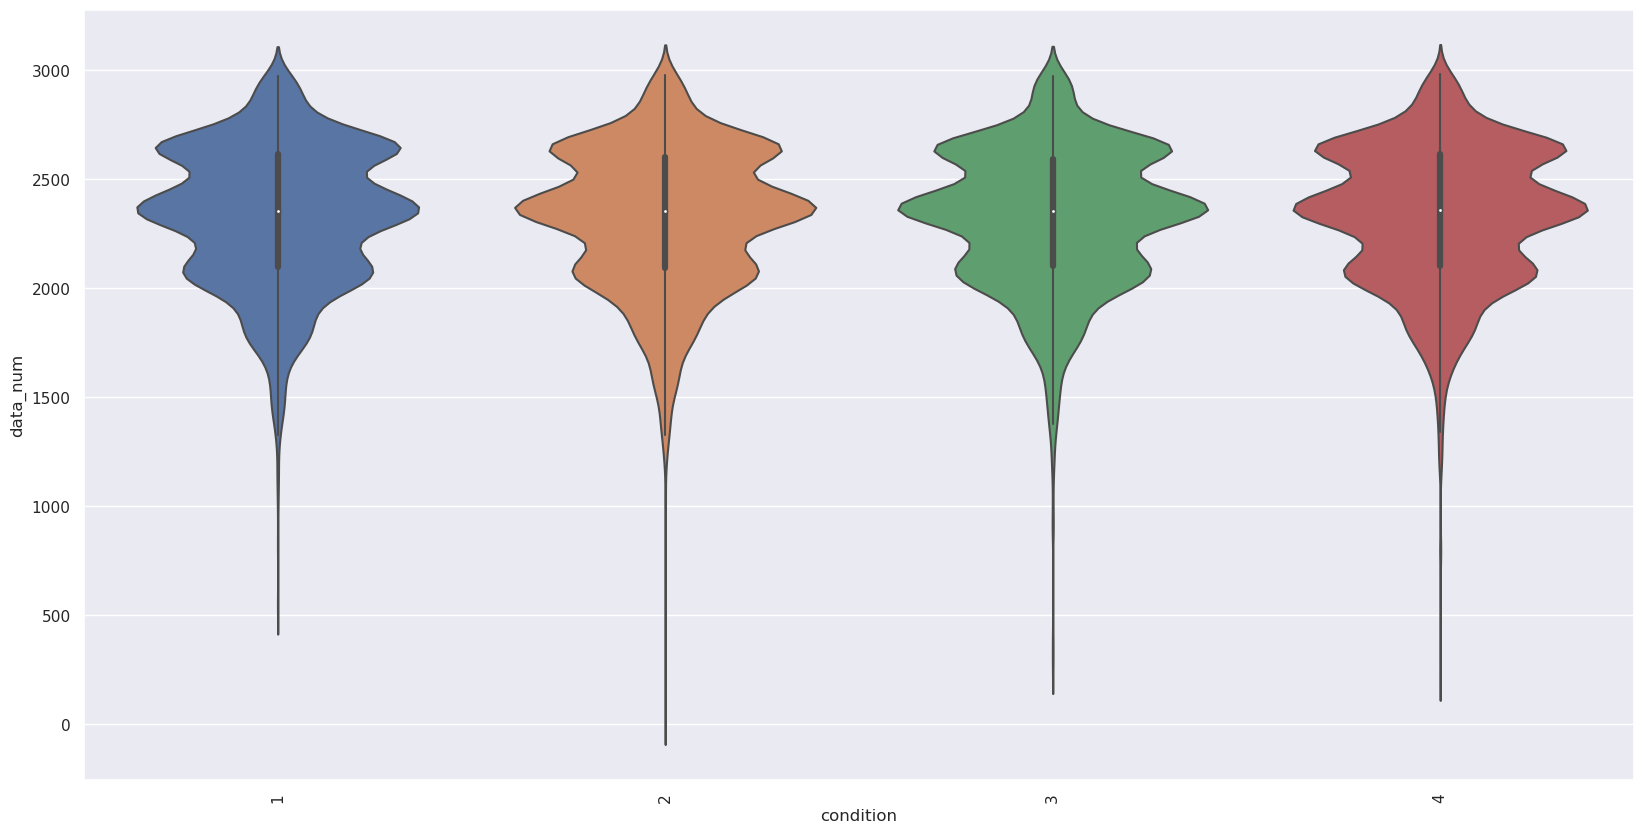

In [115]:
# plot amount of data per subject as violinplot with overlayed swarmplot

# convert data_num column to numeric
trials_used_df['data_num'] = pd.to_numeric(trials_used_df['data_num'])

# exclude subject 9
trials_used_df = trials_used_df[trials_used_df['sub'] != 'sub-09']

# exclude trials with no data
trials_used_df = trials_used_df[trials_used_df['data_num'] > 0]

sns.violinplot(x='condition',y="data_num", data=trials_used_df) #draws the lines

# rotate x axis labels
plt.xticks(rotation=90)

# make plot much wider
plt.gcf().set_size_inches(20, 10)

In [116]:
# mean across data_num for each subject
a = trials_used_df.groupby('sub')['data_num'].mean()

# print mean and std for a
print(a.mean())
print(a.std())

2328.1338636077307
236.68532855612756


In [117]:
# how many trials have less than 500ms of data?
len(trials_used_df[trials_used_df['data_num'] < 500])

5

In [121]:
trials_used_df.loc[trials_used_df['data'] == 'yes']['condition'].value_counts() 

condition
4    2396
1    2395
2    2395
3    2393
Name: count, dtype: int64

In [46]:
import copy
# for each sub, add 'yes' or 'no' tag to df based on onsets in trials_used_df

df_big = pd.DataFrame(columns=["sub", "onset", "duration", "trial_type", 'run', "data"])

for sub in subs:

    # get event files, which are divided by runs, and append into one big df
    for run in ['01', '02', '03', '04']:
        # get event files
        event_file = os.path.join(eye_data_path, sub, sub + '_task-probe_run-' + run + '_events.tsv')
        # read in event file
        df = pd.read_csv(event_file, sep='\t')
        # add run column
        df['run'] = run[-1]
        # append to big df
        if run == '01':
            df_all = df
        else:
            df_2 = df
            # concatenate
            df_all = pd.concat([df_all, df_2], ignore_index=True)

    # include only trial types in conditions or 'probe'
    # df_all = df_all[df_all['trial_type'].isin(conditions) | (df_all['trial_type'] == 'probe')]
    print(df_all.head())
    # print unique trial types
    print(df_all['trial_type'].unique())

    # get trials_used_sub_df
    trials_used_sub_df = copy.deepcopy(trials_used_df[trials_used_df['sub'] == sub])

    # for each row in df_all, look for corresponding onset in trials_used_sub_df
    for i in range(len(df_all)):
        onset_check = df_all.iloc[i]['onset']
        print('onset_check', onset_check)
        condition_check = df_all.iloc[i]['trial_type']
        print('condition_check', condition_check)

        # check if onset is in trials_used_sub_df
        # filter by condition
        trials_used_sub_df_cond = trials_used_sub_df[trials_used_sub_df['condition'] == condition_check]
        # filter by onset but use range of 1s to account for rounding errors

        trials_used_sub_df_onset = trials_used_sub_df_cond[(trials_used_sub_df_cond['onset'] >= onset_check - 1) & (trials_used_sub_df_cond['onset'] <= onset_check + 1)]
        # should be length 1

        print('trials_used_sub_df_onset', trials_used_sub_df_onset)

        if len(trials_used_sub_df_onset) == 1:
            data = trials_used_sub_df_onset.iloc[0]['data']
        else:
            data = 'weird'

        # add to df_all
        print('data', data)
        # add value where onset is onset_check and condition is condition_check
        df_all.loc[(df_all['onset'] == onset_check) & (df_all['trial_type'] == condition_check), 'data'] = data

    #print(df_all.head())

    # add column for sub
    df_all['sub'] = sub

    # add to df_big
    df_big = pd.concat([df_big, df_all], ignore_index=True)


        onset  duration trial_type  stimulus run
0  358.799436       2.0          3      33.0   1
1  358.799436       2.0   stimulus      33.0   1
2  362.381885       2.0   stimulus      34.0   1
3  362.381885       2.0          4      34.0   1
4  365.414362       2.0   stimulus      61.0   1
['3' 'stimulus' '4' '1' 'probe' 'new_screen_missed' '2' 'right'
 'new_screen_right']
onset_check 358.7994360599518
condition_check 3
trials_used_sub_df_onset         sub condition    onset run data
128  sub-01         3  358.799  04  yes
data yes
onset_check 358.7994360599518
condition_check stimulus
trials_used_sub_df_onset Empty DataFrame
Columns: [sub, condition, onset, run, data]
Index: []
data weird
onset_check 362.3818850193024
condition_check stimulus
trials_used_sub_df_onset Empty DataFrame
Columns: [sub, condition, onset, run, data]
Index: []
data weird
onset_check 362.3818850193024
condition_check 4
trials_used_sub_df_onset         sub condition    onset run data
192  sub-01         4  3

/tmp/ipykernel_96012/1990950383.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_big = pd.concat([df_big, df_all], ignore_index=True)


        onset  duration        trial_type  stimulus run
0   96.497406   2.00000                 3      34.0   1
1   96.497406   2.00000          stimulus      34.0   1
2   98.999324   1.20072             probe       NaN   1
3  100.200044   0.00000             right       NaN   1
4  100.200044   3.19928  new_screen_right       NaN   1
['3' 'stimulus' 'probe' 'right' 'new_screen_right' '2' '4' '1']
onset_check 96.49740597343444
condition_check 3
trials_used_sub_df_onset         sub condition   onset run data
384  sub-07         3  96.497  04  yes
data yes
onset_check 96.49740597343444
condition_check stimulus
trials_used_sub_df_onset Empty DataFrame
Columns: [sub, condition, onset, run, data]
Index: []
data weird
onset_check 98.99932384490968
condition_check probe
trials_used_sub_df_onset Empty DataFrame
Columns: [sub, condition, onset, run, data]
Index: []
data weird
onset_check 100.2000436782837
condition_check right
trials_used_sub_df_onset Empty DataFrame
Columns: [sub, condition, on

In [48]:
# remove trial types of stimulus
df_big = df_big[~df_big['trial_type'].str.contains('stimulus')]

df_big.head()

,sub,onset,duration,trial_type,run,data,stimulus
0,sub-01,358.799436,2.000000,3,1,yes,33.0
3,sub-01,362.381885,2.000000,4,1,yes,34.0
5,sub-01,365.414362,2.000000,1,1,yes,61.0
6,sub-01,367.798906,1.019164,probe,1,weird,NaN
7,sub-01,368.818070,3.380836,new_screen_missed,1,weird,NaN


In [37]:
# how many bad data points?
df_big.loc[df_big['data'] == 'no']['trial_type'].value_counts()

trial_type
3    103
1    101
2    101
4    100
Name: count, dtype: int64

In [49]:
# add 'previous trial' column to df_big
df_big['previous_trial'] = df_big['stimulus'].shift(1)

# for first trial (lowest onset) in each run for ech subjects, previous trial is 'nan'
df_big.loc[df_big['onset'] == df_big.groupby(['sub', 'run'])['onset'].transform('min'), 'previous_trial'] = 'nan'

df_big.head()



/tmp/ipykernel_96012/3947561919.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_big.loc[df_big['onset'] == df_big.groupby(['sub', 'run'])['onset'].transform('min'), 'previous_trial'] = 'nan'


,sub,onset,duration,trial_type,run,data,stimulus,previous_trial
0,sub-01,358.799436,2.000000,3,1,yes,33.0,nan
3,sub-01,362.381885,2.000000,4,1,yes,34.0,33.0
5,sub-01,365.414362,2.000000,1,1,yes,61.0,34.0
6,sub-01,367.798906,1.019164,probe,1,weird,NaN,61.0
7,sub-01,368.818070,3.380836,new_screen_missed,1,weird,NaN,NaN


In [50]:
# take only rows where data is 'yes'
df_big = df_big[df_big['data'] == 'yes']
df_big.head()

,sub,onset,duration,trial_type,run,data,stimulus,previous_trial
0,sub-01,358.799436,2.0,3,1,yes,33.0,nan
3,sub-01,362.381885,2.0,4,1,yes,34.0,33.0
5,sub-01,365.414362,2.0,1,1,yes,61.0,34.0
8,sub-01,373.579071,2.0,2,1,yes,32.0,NaN
10,sub-01,376.611448,2.0,3,1,yes,33.0,32.0


In [62]:
# we only need to look at trial type 2 and 3 
df_big = df_big[df_big['trial_type'].isin(['2', '3'])]


# take only rows where previpous_trial is greater than 0
df_big = df_big[df_big['previous_trial'] > 0]

df_big.head()

,sub,onset,duration,trial_type,run,data,stimulus,previous_trial
10,sub-01,376.611448,2.0,3,1,yes,33.0,32.0
15,sub-01,382.943184,2.0,2,1,yes,37.0,71.0
17,sub-01,386.975613,2.0,2,1,yes,67.0,37.0
24,sub-01,397.839384,2.0,3,1,yes,38.0,31.0
28,sub-01,409.436796,2.0,2,1,yes,67.0,74.0


In [73]:
# create new column which is last digit of int value of stimulus
# do ame for previous trial

df_big['stimulus_last_digit'] = df_big['stimulus'].astype(int) % 10
df_big['previous_trial_last_digit'] = df_big['previous_trial'].astype(int) % 10

df_big.head()

,sub,onset,duration,trial_type,run,data,stimulus,previous_trial,stimulus_last_digit,previous_trial_last_digit
10,sub-01,376.611448,2.0,3,1,yes,33.0,32.0,3,2
15,sub-01,382.943184,2.0,2,1,yes,37.0,71.0,7,1
17,sub-01,386.975613,2.0,2,1,yes,67.0,37.0,7,7
24,sub-01,397.839384,2.0,3,1,yes,38.0,31.0,8,1
28,sub-01,409.436796,2.0,2,1,yes,67.0,74.0,7,4


In [74]:
# for each sub, for each trial type, get percentage of trials where previous_trial < stimulus

# take only rows where previpous_trial is a number
df_big = df_big[df_big['previous_trial'] != 'nan']

# create empty df with columns "sub", "trial_type", "percentage_previous_trial_lower"

percentage_df = pd.DataFrame(columns=["sub", "trial_type", "percentage_previous_trial_lower", 'percentage_previous_trial_higher', 'percentage_previous_trial_same'])


for sub in subs:
    for trial_type in ['2', '3']:
        # get df for sub and trial_type
        df_sub = df_big[(df_big['sub'] == sub) & (df_big['trial_type'] == trial_type)]

        if len(df_sub) == 0:
            continue

        # get percentage of trials where previous_trial < stimulus
        percentage_low = len(df_sub[df_sub['previous_trial'] < df_sub['stimulus']]) / len(df_sub)
        percentage_high = len(df_sub[df_sub['previous_trial'] > df_sub['stimulus']]) / len(df_sub)
        percentage_same = len(df_sub[df_sub['previous_trial'] == df_sub['stimulus']]) / len(df_sub)

        # same for last_digit
        percentage_low_last_digit = len(df_sub[df_sub['previous_trial_last_digit'] < df_sub['stimulus_last_digit']]) / len(df_sub)
        percentage_high_last_digit = len(df_sub[df_sub['previous_trial_last_digit'] > df_sub['stimulus_last_digit']]) / len(df_sub)
        percentage_same_last_digit = len(df_sub[df_sub['previous_trial_last_digit'] == df_sub['stimulus_last_digit']]) / len(df_sub)
        # add to percentage_df
        row_df = pd.DataFrame([[sub, trial_type, percentage_low, percentage_high, percentage_same, percentage_high_last_digit, percentage_low_last_digit, percentage_same_last_digit]], columns=["sub", "trial_type", "percentage_previous_trial_lower", 'percentage_previous_trial_higher', 'percentage_previous_trial_same', 'percentage_previous_trial_higher_last_digit', 'percentage_previous_trial_lower_last_digit', 'percentage_previous_trial_same_last_digit'])
        percentage_df = pd.concat([percentage_df, row_df], ignore_index=True)


/tmp/ipykernel_96012/301119344.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  percentage_df = pd.concat([percentage_df, row_df], ignore_index=True)


In [75]:
percentage_df

,sub,trial_type,percentage_previous_trial_lower,percentage_previous_trial_higher,percentage_previous_trial_same,percentage_previous_trial_higher_last_digit,percentage_previous_trial_lower_last_digit,percentage_previous_trial_same_last_digit
0,sub-01,2,0.479167,0.500000,0.020833,0.437500,0.437500,0.125000
1,sub-01,3,0.468085,0.510638,0.021277,0.404255,0.489362,0.106383
2,sub-07,2,0.437500,0.520833,0.041667,0.437500,0.416667,0.145833
3,sub-07,3,0.458333,0.500000,0.041667,0.229167,0.666667,0.104167
4,sub-10,2,0.458333,0.541667,0.000000,0.458333,0.312500,0.229167
...,...,...,...,...,...,...,...,...
71,sub-60,3,0.500000,0.500000,0.000000,0.395833,0.458333,0.145833
72,sub-61,2,0.416667,0.541667,0.041667,0.541667,0.312500,0.145833
73,sub-61,3,0.458333,0.541667,0.000000,0.395833,0.520833,0.083333
74,sub-62,2,0.666667,0.291667,0.041667,0.333333,0.500000,0.166667


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


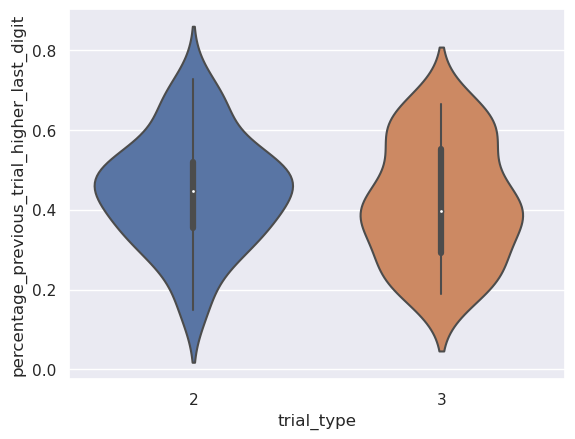

In [78]:
import seaborn as sns

sns.set(style="darkgrid")

# plot as violinplot, x is trial_type, y is percentage_previous_trial_lower
ax = sns.violinplot(x="trial_type", y="percentage_previous_trial_higher_last_digit", data=percentage_df)

In [ ]:
# so most trials are HIGHER for position 2, meaning you would look LEFT to get there
# and most trials are LOWER for position 3, meaning you would look RIGHT to get there

# is it possible to say that they look left before stimulus, then right to go to centre?
# no: we see clear movement relative to starting point of trial

# WHAT DOES OUR DATA LOOK LIKE?

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

<Axes: xlabel='mean_x', ylabel='mean_y'>

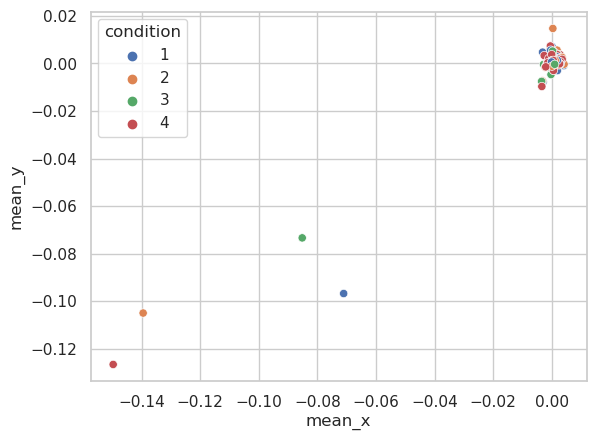

In [ ]:
# plot mean x and y coordinates for each condition

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Plot the responses for different events and regions as points on a scattplot where axes are mean x and mean y
sns.scatterplot(x="mean_x", y="mean_y",
                hue="condition", 
                data=summary_df)

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

<Axes: xlabel='mean_x', ylabel='mean_y'>

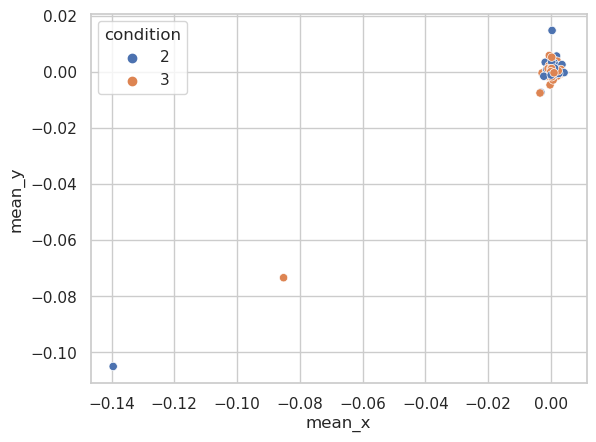

In [ ]:
# plot only conditions 2 and 3
sns.scatterplot(x="mean_x", y="mean_y",
                hue="condition", 
                data=summary_df[summary_df['condition'].isin(['2', '3'])])

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

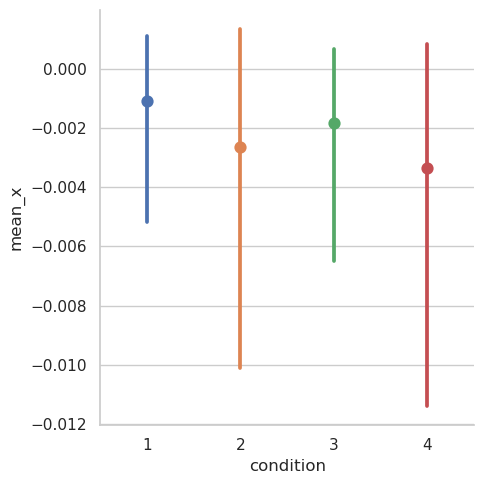

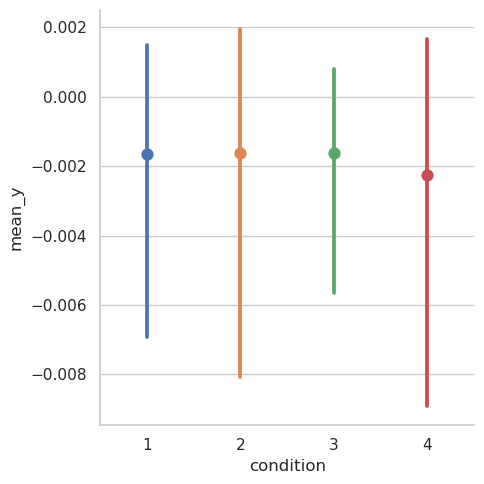

In [ ]:
# plot mean x and y coordinates for each condition, with error bars
sns.catplot(x="condition", y="mean_x", kind="point", data=summary_df, join=False, hue='condition')
sns.catplot(x="condition", y="mean_y", kind="point", data=summary_df, join=False, hue='condition')


In [ ]:

from scipy.stats import ttest_ind

mean_x_cond1 = summary_df[summary_df['condition'] == '1']['mean_x'].values
mean_x_cond2 = summary_df[summary_df['condition'] == '2']['mean_x'].values
mean_x_cond3 = summary_df[summary_df['condition'] == '3']['mean_x'].values
mean_x_cond4 = summary_df[summary_df['condition'] == '4']['mean_x'].values

mean_y_cond1 = summary_df[summary_df['condition'] == '1']['mean_y'].values
mean_y_cond2 = summary_df[summary_df['condition'] == '2']['mean_y'].values
mean_y_cond3 = summary_df[summary_df['condition'] == '3']['mean_y'].values
mean_y_cond4 = summary_df[summary_df['condition'] == '4']['mean_y'].values

In [ ]:
# test if mean_x_cond3 < mean_x_cond2

ttest_ind(mean_x_cond3, mean_x_cond2, alternative='less')

TtestResult(statistic=0.18686767556031458, pvalue=0.5738688362031189, df=76.0)

In [ ]:
# test if mean_y_cond3 < mean_y_cond2

ttest_ind(mean_y_cond3, mean_y_cond2, alternative='less')

TtestResult(statistic=0.0009339197375436456, pvalue=0.5003713564715886, df=76.0)

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

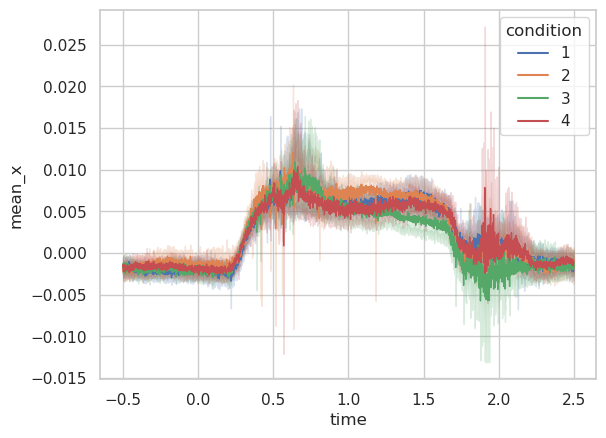

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

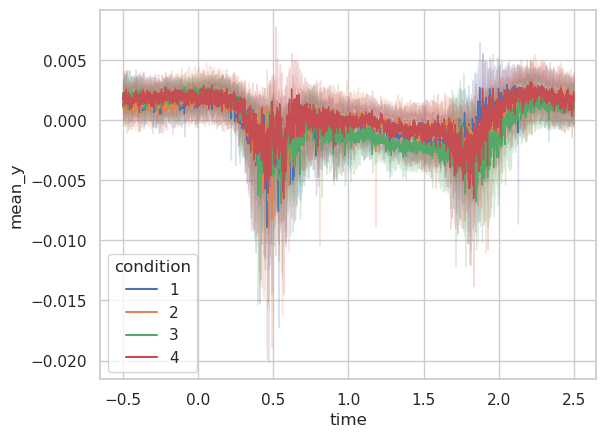

In [ ]:
# plot timecourse of gaze for each condition

# thick lines
'''
g = sns.lineplot(x="time", y="mean_x",
            data=timecourse_df,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1,
            err_style='band'

            ) 

# plot
plt.show()

# save in /data/pt_02747/action_hippo/data/derivatives/eyetracker/
g.figure.savefig(os.path.join(eye_data_path, 'timecourse_gaze_x.png'))



g = sns.lineplot(x="time", y="mean_y",
            data=timecourse_df,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1
            #errorbar=None
            )

plt.show()

# save in /data/pt_02747/action_hippo/data/derivatives/eyetracker/
g.figure.savefig(os.path.join(eye_data_path, 'timecourse_gaze_y.png'))


# save timecourse df
timecourse_df.to_csv(os.path.join(eye_data_path, 'timecourse_gaze.csv'), index=False)

# save summary df
summary_df.to_csv(os.path.join(eye_data_path, 'summary_gaze.csv'), index=False)
'''

In [ ]:
import copy
smoothed_timecourse_df = copy.deepcopy(timecourse_df)

# smooth data with gaussian filter

from scipy.ndimage import gaussian_filter1d

# for each subject
for sub in subs:
    # for each condition
    for cond in conditions:
        data_to_smooth_x = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_x'].values
        data_to_smooth_y = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_y'].values

        smoothed_data_x = gaussian_filter1d(data_to_smooth_x, sigma=100)
        smoothed_data_y = gaussian_filter1d(data_to_smooth_y, sigma=100)

        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_x'] = smoothed_data_x
        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_y'] = smoothed_data_y

In [ ]:
len(data_to_smooth_x)

3000

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

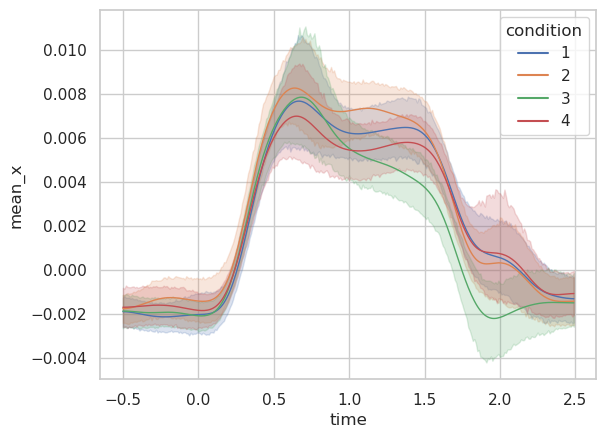

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

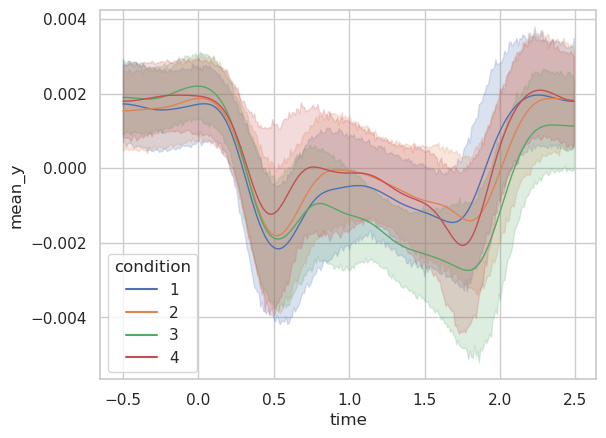

In [ ]:

# downsample smoothed timecourse df by only taking every 20th row
smoothed_timecourse_df_plot = smoothed_timecourse_df.iloc[::20, :]


g = sns.lineplot(x="time", y="mean_x",
            data=smoothed_timecourse_df_plot,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1,
            err_style='band'

            ) 

# plot
plt.show()



g = sns.lineplot(x="time", y="mean_y",
            data=smoothed_timecourse_df_plot,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1
            #errorbar=None
            )

plt.show()

In [ ]:
# save df
#data_path = '/data/pt_02747/action_hippo/code/eye_data/'
#smoothed_timecourse_df.to_csv(os.path.join(data_path, 'smoothed_timecourse_gaze.csv'), index=False)


# RUN RSA

In [ ]:
# before we carry on, let's make an error if we never got any data for timecourse_df
if len(timecourse_df) == 0:
    raise ValueError('timecourse_df is empty, check the code')

In [1]:
import sys
import os
import numpy as np
import pandas as pd

In [33]:
# load data

file = '/data/pt_02747/action_hippo/data/derivatives/eyetracker/'
conditions = ['1', '2', '3', '4']


timecourse_df = pd.read_csv(os.path.join(file, '20240827_timecourse_df.csv'), sep=',')

import copy
smoothed_timecourse_df = copy.deepcopy(timecourse_df)


# subs are unique entries in sub column
subs = timecourse_df['sub'].unique()
conditions = timecourse_df['condition'].unique()

# smooth data with gaussian filter

"""
from scipy.ndimage import gaussian_filter1d

# for each subject
for sub in subs:
    # for each condition
    for cond in conditions:
        data_to_smooth_x = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_x'].values
        data_to_smooth_y = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_y'].values

        smoothed_data_x = gaussian_filter1d(data_to_smooth_x, sigma=100)
        smoothed_data_y = gaussian_filter1d(data_to_smooth_y, sigma=100)

        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_x'] = smoothed_data_x
        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_y'] = smoothed_data_y

"""

"\nfrom scipy.ndimage import gaussian_filter1d\n\n# for each subject\nfor sub in subs:\n    # for each condition\n    for cond in conditions:\n        data_to_smooth_x = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_x'].values\n        data_to_smooth_y = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_y'].values\n\n        smoothed_data_x = gaussian_filter1d(data_to_smooth_x, sigma=100)\n        smoothed_data_y = gaussian_filter1d(data_to_smooth_y, sigma=100)\n\n        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_x'] = smoothed_data_x\n        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_y'] = smoothed_data_y\n\n"

In [34]:
# rename mean_gaze_x and mean_gaze_y to mean_x and mean_y

timecourse_df = timecourse_df.rename(columns={'mean_gaze_x': 'mean_x', 'mean_gaze_y': 'mean_y'})

# remove time column
timecourse_df = timecourse_df.drop(columns=['time'])

# rename time_rounded_relative to time

timecourse_df = timecourse_df.rename(columns={'time_rounded_relative': 'time'})

timecourse_df.head()

,sub,condition,mean_x,mean_y,time,method,time_rounded,timecourse_val,n_nans
0,sub-01,1,-0.005618,-0.016983,-0.501,mean,1180.789216,NaN,0.0
1,sub-01,1,-0.004393,-0.016716,-0.500,mean,1167.933808,NaN,0.0
2,sub-01,1,-0.005996,-0.016273,-0.499,mean,1234.038524,NaN,0.0
3,sub-01,1,-0.003557,-0.016219,-0.498,mean,1172.279071,NaN,0.0
4,sub-01,1,-0.004696,-0.017741,-0.497,mean,1049.580444,NaN,0.0


In [35]:
smoothed_timecourse_df = timecourse_df

In [12]:
# downsample smoothed timecourse df by only taking every 20th row
smoothed_timecourse_df_plot = smoothed_timecourse_df.iloc[::10, :]

import seaborn as sns
import matplotlib.pyplot as plt


g = sns.lineplot(x="time", y="mean_x",
            data=smoothed_timecourse_df_plot,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1,
            err_style='band'

            ) 

# plot
plt.show()

ValueError: Could not interpret value `mean_x` for parameter `y`

In [36]:
# add new columns to df for distances in x, y, and 2D for each combination of conditions

# this will make a really really big df, but that is ok


# for now let's test on a subset of all times below -0.45 for sub-01
#smoothed_timecourse_df_subset = copy.deepcopy(smoothed_timecourse_df[(smoothed_timecourse_df['sub'] == 'sub-01')])
smoothed_timecourse_df_subset = copy.deepcopy(smoothed_timecourse_df)
smoothed_timecourse_df_subset.head()

,sub,condition,mean_x,mean_y,time,method,time_rounded,timecourse_val,n_nans
0,sub-01,1,-0.005618,-0.016983,-0.501,mean,1180.789216,NaN,0.0
1,sub-01,1,-0.004393,-0.016716,-0.500,mean,1167.933808,NaN,0.0
2,sub-01,1,-0.005996,-0.016273,-0.499,mean,1234.038524,NaN,0.0
3,sub-01,1,-0.003557,-0.016219,-0.498,mean,1172.279071,NaN,0.0
4,sub-01,1,-0.004696,-0.017741,-0.497,mean,1049.580444,NaN,0.0


In [37]:
# add 'cond_' to the start of all entries in 'condition' column
smoothed_timecourse_df_subset['condition'] = 'cond_' + smoothed_timecourse_df_subset['condition'].astype(str)

# make conditions '1', '2', '3' and '4' rows into columns
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset.pivot(index=['time', 'sub'], columns='condition', values=['mean_x', 'mean_y'])


In [38]:
smoothed_timecourse_df_subset

mean_x                                  mean_y            \
condition        cond_1    cond_2    cond_3    cond_4    cond_1    cond_2   
time   sub                                                                  
-0.501 sub-01 -0.005618 -0.003866 -0.004050 -0.004369 -0.016983 -0.015059   
       sub-07 -0.002192 -0.001590 -0.001740 -0.002252 -0.015757 -0.017058   
       sub-10 -0.001385 -0.003409 -0.000524 -0.000504 -0.008358 -0.010356   
       sub-11  0.006212  0.007347  0.006154  0.006955 -0.021237 -0.018743   
       sub-12  0.008465  0.007961  0.006443  0.006839 -0.000160 -0.005718   
...                 ...       ...       ...       ...       ...       ...   
 2.499 sub-58  0.005636  0.004547  0.007118  0.008375 -0.016388 -0.018702   
       sub-59  0.006895  0.006393  0.006066  0.004395 -0.018321 -0.018620   
       sub-60  0.008148  0.006127  0.006953  0.008444 -0.012630 -0.010741   
       sub-61 -0.011917 -0.009485 -0.007652 -0.008769  0.000558 -0.000117   
       sub-62 -0.008726 -0.007893 -0.005880 -0.010367 -0.005729 -0.010288   

                                   
condition        cond_3    cond_4  
time   sub                         
-0.501 sub-01 -0.017145 -0.011782  
       sub-07 -0.020450 -0.018282  
       sub-10 -0.011488 -0.009627  
       sub-11 -0.019549 -0.017686  
       sub-12 -0.007060 -0.005752  
...                 ...       ...  
 2.499 sub-58 -0.017703 -0.019707  
       sub-59 -0.016535 -0.021161  
       sub-60 -0.012474 -0.014805  
       sub-61  0.001038  0.001178  
       sub-62 -0.008811 -0.006656  

[129043 rows x 8 columns]

In [39]:
# add condition columns ['12', '13', '14', '23', '24', '34'] to df

comp_conds = ['12', '13', '14', '23', '24', '34']
axis_comp = ['x', 'y', '2d']

for comp in comp_conds:
    for axis in axis_comp:
        if axis == 'x' or axis == 'y':
            smoothed_timecourse_df_subset['mean_' + axis, comp] = np.abs(smoothed_timecourse_df_subset['mean_' + axis, 'cond_'+comp[0]] - smoothed_timecourse_df_subset['mean_' + axis, 'cond_'+comp[1]])
        elif axis == '2d':
            #smoothed_timecourse_df_subset['mean_' + axis, comp] = np.sqrt(smoothed_timecourse_df_subset['mean_x', 'cond_'+comp[0]]**2 + smoothed_timecourse_df_subset['mean_y', 'cond_'+comp[1]]**2)
            x_diff = smoothed_timecourse_df_subset['mean_x', 'cond_'+comp[0]] - smoothed_timecourse_df_subset['mean_x', 'cond_'+comp[1]]
            y_diff = smoothed_timecourse_df_subset['mean_y', 'cond_'+comp[0]] - smoothed_timecourse_df_subset['mean_y', 'cond_'+comp[1]]
            smoothed_timecourse_df_subset['mean_' + axis, comp] = np.sqrt(x_diff**2 + y_diff**2)
smoothed_timecourse_df_subset.head()



mean_x                                  mean_y            \
condition        cond_1    cond_2    cond_3    cond_4    cond_1    cond_2   
time   sub                                                                  
-0.501 sub-01 -0.005618 -0.003866 -0.004050 -0.004369 -0.016983 -0.015059   
       sub-07 -0.002192 -0.001590 -0.001740 -0.002252 -0.015757 -0.017058   
       sub-10 -0.001385 -0.003409 -0.000524 -0.000504 -0.008358 -0.010356   
       sub-11  0.006212  0.007347  0.006154  0.006955 -0.021237 -0.018743   
       sub-12  0.008465  0.007961  0.006443  0.006839 -0.000160 -0.005718   

                                     mean_x    mean_y  ...   mean_2d  \
condition        cond_3    cond_4        12        12  ...        14   
time   sub                                             ...             
-0.501 sub-01 -0.017145 -0.011782  0.001752  0.001924  ...  0.005348   
       sub-07 -0.020450 -0.018282  0.000602  0.001301  ...  0.002525   
       sub-10 -0.011488 -0.009627  0.002024  0.001999  ...  0.001545   
       sub-11 -0.019549 -0.017686  0.001135  0.002495  ...  0.003628   
       sub-12 -0.007060 -0.005752  0.000504  0.005558  ...  0.005824   

                 mean_x    mean_y   mean_2d    mean_x    mean_y   mean_2d  \
condition            23        23        23        24        24        24   
time   sub                                                                  
-0.501 sub-01  0.000184  0.002087  0.002095  0.000503  0.003276  0.003315   
       sub-07  0.000150  0.003392  0.003395  0.000662  0.001224  0.001391   
       sub-10  0.002886  0.001132  0.003100  0.002905  0.000730  0.002995   
       sub-11  0.001192  0.000807  0.001440  0.000391  0.001057  0.001127   
       sub-12  0.001517  0.001343  0.002026  0.001121  0.000035  0.001122   

                 mean_x    mean_y   mean_2d  
condition            34        34        34  
time   sub                                   
-0.501 sub-01  0.000319  0.005363  0.005372  
       sub-07  0.000512  0.002168  0.002228  
       sub-10  0.000019  0.001861  0.001862  
       sub-11  0.000801  0.001863  0.002028  
       sub-12  0.000396  0.001308  0.001366  

[5 rows x 26 columns]

In [8]:
# remove sub-09
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset[smoothed_timecourse_df_subset.index.get_level_values('sub') != 'sub-09']

In [40]:
# add affordance dictionary to df

aff_dict = {'12': 1,
            '13': 1,
            '14': 0,
            '23': 2,
            '24': 1,
            '34': 1}



for comp in comp_conds:
    smoothed_timecourse_df_subset['aff_dict', comp] = aff_dict[comp]

smoothed_timecourse_df_subset.head()

mean_x                                  mean_y            \
condition        cond_1    cond_2    cond_3    cond_4    cond_1    cond_2   
time   sub                                                                  
-0.501 sub-01 -0.005618 -0.003866 -0.004050 -0.004369 -0.016983 -0.015059   
       sub-07 -0.002192 -0.001590 -0.001740 -0.002252 -0.015757 -0.017058   
       sub-10 -0.001385 -0.003409 -0.000524 -0.000504 -0.008358 -0.010356   
       sub-11  0.006212  0.007347  0.006154  0.006955 -0.021237 -0.018743   
       sub-12  0.008465  0.007961  0.006443  0.006839 -0.000160 -0.005718   

                                     mean_x    mean_y  ...   mean_2d  \
condition        cond_3    cond_4        12        12  ...        24   
time   sub                                             ...             
-0.501 sub-01 -0.017145 -0.011782  0.001752  0.001924  ...  0.003315   
       sub-07 -0.020450 -0.018282  0.000602  0.001301  ...  0.001391   
       sub-10 -0.011488 -0.009627  0.002024  0.001999  ...  0.002995   
       sub-11 -0.019549 -0.017686  0.001135  0.002495  ...  0.001127   
       sub-12 -0.007060 -0.005752  0.000504  0.005558  ...  0.001122   

                 mean_x    mean_y   mean_2d aff_dict                 
condition            34        34        34       12 13 14 23 24 34  
time   sub                                                           
-0.501 sub-01  0.000319  0.005363  0.005372        1  1  0  2  1  1  
       sub-07  0.000512  0.002168  0.002228        1  1  0  2  1  1  
       sub-10  0.000019  0.001861  0.001862        1  1  0  2  1  1  
       sub-11  0.000801  0.001863  0.002028        1  1  0  2  1  1  
       sub-12  0.000396  0.001308  0.001366        1  1  0  2  1  1  

[5 rows x 32 columns]

In [41]:
# define tie-corrected rank correlation based on previous stuff
import scipy
def compare_rho_a(vector1, vector2):
    """calculates the spearman rank correlations between
    two RDMs objects without tie correction

    Args:
        v1, v2 (numpy.ndarray): RDMs to be compared
    Returns:
        numpy.ndarray: dist:
            rank correlations between the two RDMs

    """

    # check input is np array and if not, make it one
    if type(vector1) is not np.ndarray:
        vector1 = np.array(vector1)
    if type(vector2) is not np.ndarray:
        vector2 = np.array(vector2)

    # check input is 2D and if not, make it one
    if len(vector1.shape) != 2:
        vector1 = np.atleast_2d(vector1)
    if len(vector2.shape) != 2:
        vector2 = np.atleast_2d(vector2)


    # check input is horizontal and if not, make it one
    if vector1.shape[0] > vector1.shape[1]:
        vector1 = vector1.T
    if vector2.shape[0] > vector2.shape[1]:
        vector2 = vector2.T
        
    vector1 = np.apply_along_axis(scipy.stats.rankdata, 1, vector1)
    vector2 = np.apply_along_axis(scipy.stats.rankdata, 1, vector2)
    vector1 = vector1 - np.mean(vector1, 1, keepdims=True)
    vector2 = vector2 - np.mean(vector2, 1, keepdims=True)
    n = vector1.shape[1]
    sim = np.einsum('ij,kj->ik', vector1, vector2) / (n ** 3 - n) * 12
    return sim[0][0]

compare_rho_a([1,2,2], [4,5,6])

0.75

In [42]:
# correlate in x, y, and 2D for each combination of conditions

# choose whether to look at x,y, or 2d
for axis in axis_comp:
    # add an empty column called 'corr_' + axis
    smoothed_timecourse_df_subset['corr_' + axis] = np.nan
    # for each row, correlate the 6 combinations of conditions
    for row_i in range(len(smoothed_timecourse_df_subset)):
        #print(row_i)
        # create two lists of values for model (from aff_dict) and data (from mean_x, mean_y, or mean_2d)
        model_vals = []
        data_vals = []
        for comp in comp_conds:
            model_vals.append(list(smoothed_timecourse_df_subset['aff_dict', comp])[row_i])
            data_vals.append(list(smoothed_timecourse_df_subset['mean_' + axis, comp])[row_i])
        # correlate model and data
        corr = compare_rho_a(model_vals, data_vals)

        if corr == 1:
            eval_corr = 0.999
        elif corr == -1:
            eval_corr = -0.999

        corr = np.arctanh(corr) # z-score

        ind = smoothed_timecourse_df_subset.index[row_i]

        # add to df, define row by index and column by 'corr_' + axis
        smoothed_timecourse_df_subset.loc[ind, 'corr_' + axis] = corr

# keep only corr columns
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset[['corr_x', 'corr_y', 'corr_2d']]

# flatten multiindex
smoothed_timecourse_df_subset.columns = smoothed_timecourse_df_subset.columns.map(''.join)

# flatten multiindex 
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset.reset_index()

# save df
data_path = '/data/pt_02747/action_hippo/code/eye_data/rsa/'
smoothed_timecourse_df_subset.to_csv(os.path.join(data_path, 'timecourse_gaze_rsa_affordance.csv'), index=False)

smoothed_timecourse_df_subset.head()


,time,sub,corr_x,corr_y,corr_2d
0,-0.501,sub-01,-0.458145,-0.293893,-0.458145
1,-0.501,sub-07,0.143841,0.143841,0.143841
2,-0.501,sub-10,0.293893,-0.143841,0.649641
3,-0.501,sub-11,0.458145,-0.895880,-0.649641
4,-0.501,sub-12,-0.143841,-0.293893,-0.293893


In [214]:
# show row indices in smoothed_timecourse_df_subset
smoothed_timecourse_df_subset

mean_x                                  mean_y            \
condition        cond_1    cond_2    cond_3    cond_4    cond_1    cond_2   
time   sub                                                                  
-0.500 sub-01 -0.004045 -0.002801 -0.003154 -0.003462  0.000265  0.000316   
       sub-07 -0.002682 -0.001870 -0.001486 -0.001824  0.005434  0.004719   
       sub-09       NaN       NaN       NaN       NaN       NaN       NaN   
       sub-10 -0.002048 -0.002931 -0.002700 -0.002886  0.001696  0.001121   
       sub-12  0.000936  0.000458 -0.000655  0.000872  0.007535  0.005406   
...                 ...       ...       ...       ...       ...       ...   
 2.499 sub-58  0.001399 -0.000914  0.002286  0.002357  0.000263 -0.001052   
       sub-59  0.003372  0.001516  0.003848  0.001736  0.003089  0.003190   
       sub-60 -0.004272 -0.007127 -0.006330 -0.003431 -0.007292 -0.007979   
       sub-61 -0.002443 -0.003037 -0.000003 -0.002918  0.002703  0.001691   
       sub-62 -0.005832 -0.006023 -0.004484 -0.008422  0.002023 -0.001664   

                                     mean_x    mean_y  ...   mean_2d aff_dict  \
condition        cond_3    cond_4        12        12  ...        34       12   
time   sub                                             ...                      
-0.500 sub-01  0.000026  0.001281  0.001244  0.000051  ...  0.003405        1   
       sub-07  0.003981  0.003612  0.000812  0.000714  ...  0.003906        1   
       sub-09       NaN       NaN       NaN       NaN  ...       NaN        1   
       sub-10 -0.000165  0.000866  0.000883  0.000575  ...  0.002835        1   
       sub-12  0.005012  0.004890  0.000478  0.002129  ...  0.004934        1   
...                 ...       ...       ...       ...  ...       ...      ...   
 2.499 sub-58 -0.000832 -0.000741  0.002314  0.001315  ...  0.002403        1   
       sub-59  0.002972  0.001330  0.001856  0.000101  ...  0.004071        1   
       sub-60 -0.007752 -0.009556  0.002855  0.000687  ...  0.011463        1   
       sub-61  0.001169  0.002808  0.000594  0.001012  ...  0.002808        1   
       sub-62 -0.000578 -0.000899  0.000191  0.003687  ...  0.004573        1   

                                corr_x    corr_y   corr_2d  
condition     13 14 23 24 34                                
time   sub                                                  
-0.500 sub-01  1  0  2  1  1 -0.143841 -0.293893 -0.895880  
       sub-07  1  0  2  1  1 -0.293893 -0.458145 -0.143841  
       sub-09  1  0  2  1  1       NaN       NaN       NaN  
       sub-10  1  0  2  1  1 -0.293893  0.293893  0.458145  
       sub-12  1  0  2  1  1  0.458145 -0.649641  0.143841  
...           .. .. .. .. ..       ...       ...       ...  
 2.499 sub-58  1  0  2  1  1  0.293893 -0.293893 -0.143841  
       sub-59  1  0  2  1  1  0.458145 -0.293893 -0.143841  
       sub-60  1  0  2  1  1 -0.143841 -0.895880  0.143841  
       sub-61  1  0  2  1  1  0.649641  0.143841 -0.143841  
       sub-62  1  0  2  1  1 -0.293893 -0.293893  0.143841  

[117000 rows x 35 columns]

In [215]:
smoothed_timecourse_df_subset.head()

mean_x                                  mean_y            \
condition      cond_1    cond_2    cond_3    cond_4    cond_1    cond_2   
time sub                                                                  
-0.5 sub-01 -0.004045 -0.002801 -0.003154 -0.003462  0.000265  0.000316   
     sub-07 -0.002682 -0.001870 -0.001486 -0.001824  0.005434  0.004719   
     sub-09       NaN       NaN       NaN       NaN       NaN       NaN   
     sub-10 -0.002048 -0.002931 -0.002700 -0.002886  0.001696  0.001121   
     sub-12  0.000936  0.000458 -0.000655  0.000872  0.007535  0.005406   

                                   mean_x    mean_y  ...   mean_2d aff_dict  \
condition      cond_3    cond_4        12        12  ...        34       12   
time sub                                             ...                      
-0.5 sub-01  0.000026  0.001281  0.001244  0.000051  ...  0.003405        1   
     sub-07  0.003981  0.003612  0.000812  0.000714  ...  0.003906        1   
     sub-09       NaN       NaN       NaN       NaN  ...       NaN        1   
     sub-10 -0.000165  0.000866  0.000883  0.000575  ...  0.002835        1   
     sub-12  0.005012  0.004890  0.000478  0.002129  ...  0.004934        1   

                              corr_x    corr_y   corr_2d  
condition   13 14 23 24 34                                
time sub                                                  
-0.5 sub-01  1  0  2  1  1 -0.143841 -0.293893 -0.895880  
     sub-07  1  0  2  1  1 -0.293893 -0.458145 -0.143841  
     sub-09  1  0  2  1  1       NaN       NaN       NaN  
     sub-10  1  0  2  1  1 -0.293893  0.293893  0.458145  
     sub-12  1  0  2  1  1  0.458145 -0.649641  0.143841  

[5 rows x 35 columns]

In [12]:
# keep only corr columns
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset[['corr_x', 'corr_y', 'corr_2d']]

# flatten multiindex
smoothed_timecourse_df_subset.columns = smoothed_timecourse_df_subset.columns.map(''.join)

# flatten multiindex 
smoothed_timecourse_df_subset = smoothed_timecourse_df_subset.reset_index()

In [217]:
smoothed_timecourse_df_subset.head()

,time,sub,corr_x,corr_y,corr_2d
0,-0.5,sub-01,-0.143841,-0.293893,-0.895880
1,-0.5,sub-07,-0.293893,-0.458145,-0.143841
2,-0.5,sub-09,NaN,NaN,NaN
3,-0.5,sub-10,-0.293893,0.293893,0.458145
4,-0.5,sub-12,0.458145,-0.649641,0.143841


In [13]:
# save df
data_path = '/data/pt_02747/action_hippo/code/eye_data/'
smoothed_timecourse_df_subset.to_csv(os.path.join(data_path, 'smoothed_timecourse_gaze_rsa_affmag.csv'), index=False)


In [223]:
# save df
data_path = '/data/pt_02747/action_hippo/code/eye_data/'
smoothed_timecourse_df.to_csv(os.path.join(data_path, 'smoothed_timecourse_gaze.csv'), index=False)


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: F

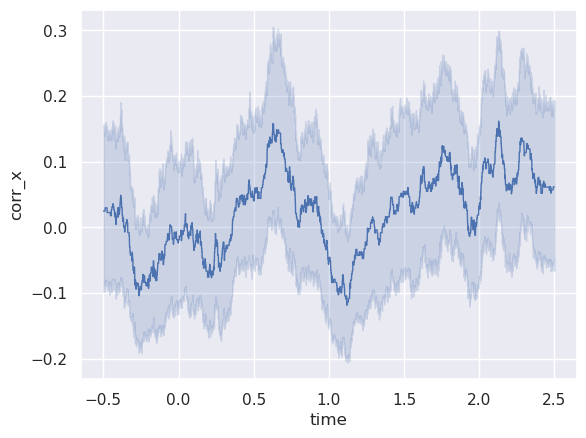

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: F

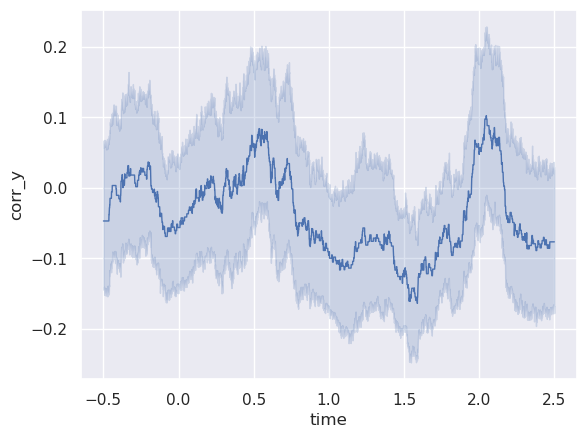

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: F

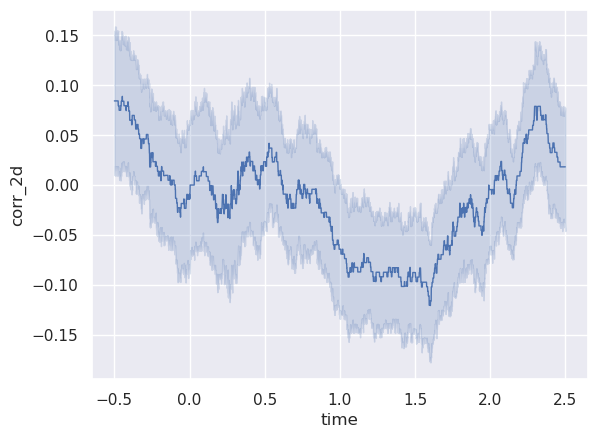

In [14]:
# plot as lineplot, x axis is time, y axis is corr_x

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")
for y_ax in ['corr_x', 'corr_y', 'corr_2d']:
    g = sns.lineplot(x="time", y=y_ax,
                data=smoothed_timecourse_df_subset,
                #hue='sub',
                errorbar=('ci', 95),
                linewidth=1,
                err_style='band'

                )
    plt.show()